# 🎯 Job Recommendation System — ML Pipeline
## Hybrid TF-IDF + Cosine Similarity | NLP Preprocessing | Skill Gap Analysis

**Purpose:** End-to-end ML pipeline — from raw CSV to ranked job recommendations

---

### Notebook Structure
1. Imports & Configuration
2. Data Loading
3. Data Cleaning & Skill Parsing
4. NLP Text Preprocessing
5. Skill Vocabulary
6. Skill Extraction
7. Feature Engineering
8. TF-IDF Vectorization
9. Experience Level Detection
10. Helper Functions
11. Recommendation Engine
12. Demo Run
13. Skill Gap Analysis
14. Evaluation
15. Save Artifacts

## 1. Imports & Configuration

In [7]:
# ── Standard Library ────────────────────────────────────
import re
import ast
import pickle
import warnings
from pathlib import Path
from collections import Counter
from difflib import SequenceMatcher

# ── Data & ML ───────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Visualization ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print('✅ All imports successful')

✅ All imports successful


In [8]:
# ════════════════════════════════════════════════════════
# CONFIGURATION
# ════════════════════════════════════════════════════════

CONFIG = {
    'data_path'            : 'all_job_post.csv',
    'output_dir'           : './artifacts',
    'skill_weight'         : 0.70,
    'desc_weight'          : 0.30,
    'skill_min_df'         : 1,
    'skill_max_df'         : 0.90,
    'desc_max_features'    : 10000,
    'desc_min_df'          : 2,
    'desc_max_df'          : 0.80,
    'top_n'                : 5,
    'candidate_multiplier' : 6,
    'category_cap'         : 0.45,
    'title_sim_threshold'  : 0.82,
    'tiers': [
        (70, 'Strong Match',  '🟢'),
        (45, 'Good Match',    '🟡'),
        (25, 'Partial Match', '🟠'),
        ( 0, 'Weak Match',    '🔴'),
    ],
}

Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
print(f"✅ Config loaded | Output dir: {CONFIG['output_dir']}")

✅ Config loaded | Output dir: ./artifacts


## 2. Data Loading

In [9]:
raw_df = pd.read_csv(CONFIG['data_path'])
print(f'Shape: {raw_df.shape}')
print(f'Columns: {raw_df.columns.tolist()}')
raw_df.head(3)

Shape: (1167, 5)
Columns: ['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTION...,"['employee relations', 'talent acquisition', 'performance management', 'comp..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGER OF HUMAN RESOURCES. JOIN US ...,"['Talent Acquisition', 'Employee Performance Management', 'Legal Compliance'..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING A UNIQUE OPPORTUNITY FOR A DI...,"['Human Resources Management', 'Recruitment', 'Employee Relations', 'Perform..."


In [10]:
print('Missing values:')
print(raw_df.isnull().sum())
print(f'\nCategory distribution:')
print(raw_df['category'].value_counts())

Missing values:
job_id             0
category           0
job_title          0
job_description    0
job_skill_set      0
dtype: int64

Category distribution:
category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                        220
Name: count, dtype: int64


## 3. Data Cleaning & Skill Parsing

In [ ]:
# ════════════════════════════════════════════════════════
# SIMPLE SKILL NORMALIZATION SYSTEM
# ════════════════════════════════════════════════════════

import re
import ast



SKILL_ALIASES = {

    # Programming Languages
    'py': 'python',
    'python3': 'python',
    'js': 'javascript',
    'nodejs': 'node.js',
    'csharp': 'c#',

   
    'ml': 'machine learning',
    'dl': 'deep learning',
    'ai': 'artificial intelligence',
    'nlp': 'natural language processing',

    
    'powerbi': 'power bi',
    'sklearn': 'scikit-learn',
    'tf': 'tensorflow',
    'torch': 'pytorch',

   
    'amazon web services': 'aws',
    'gcp': 'google cloud platform',
    'k8s': 'kubernetes',

    
    'postgres': 'postgresql',
    'mongo': 'mongodb',

   
    'reactjs': 'react',
    'vuejs': 'vue',
    'nextjs': 'next.js',

    
    'ms excel': 'excel',
    'microsoft excel': 'excel',

    
    'team work': 'teamwork',
    'problem-solving': 'problem solving',
    'time-management': 'time management',
}


# ════════════════════════════════════════════════════════
# FUNCTION 1 → Normalize Single Skill
# ════════════════════════════════════════════════════════

def normalize_skill(skill):

    
    if not isinstance(skill, str):
        return ''

   
    skill = skill.lower().strip()

   
    if skill == '':
        return ''

    
    skill = re.sub(r'[^a-z0-9+#./ -]', '', skill)

   
    skill = re.sub(r'\s+', ' ', skill).strip()

   
    skill = SKILL_ALIASES.get(skill, skill)

    
    return skill


# ════════════════════════════════════════════════════════
# FUNCTION 2 → Convert Full Skill List
# ════════════════════════════════════════════════════════

def parse_skill_list(skill_str):

    
    if not isinstance(skill_str, str) or skill_str.strip() == '':
        return []

    try:
        
        raw_skills = ast.literal_eval(skill_str)

       
        if not isinstance(raw_skills, list):
            raw_skills = []

    except:

        
        raw_skills = skill_str.split(',')

   
    cleaned_skills = []

    for skill in raw_skills:

        # Har skill normalize karo
        skill = normalize_skill(skill)

        # Empty values skip karo
        if skill != '':
            cleaned_skills.append(skill)

    # Duplicate remove karo
    cleaned_skills = list(set(cleaned_skills))

    # Final skill list return
    return cleaned_skills


# ════════════════════════════════════════════════════════
# EXAMPLE
# ════════════════════════════════════════════════════════

skills = "Python, PY, ML, js, ReactJS, Mongo"

result = parse_skill_list(skills)

print(result)

['react', 'machine learning', 'javascript', 'mongodb', 'python']


In [30]:
# ════════════════════════════════════════════════════════
# CLEAN & REMOVE DUPLICATES FROM DATASET
# ════════════════════════════════════════════════════════

import pandas as pd


# ------------------------------------------------
# STEP 1 → Required columns select karo
# ------------------------------------------------



required_cols = [

    col for col in [

        'job_id',
        'category',
        'job_title',
        'job_description',
        'job_skill_set'

    ]

    if col in raw_df.columns
]



df = raw_df[required_cols].copy()



# ------------------------------------------------
# STEP 2 → Missing title/skills remove karo
# ------------------------------------------------

before = len(df)


df.dropna(

    subset=['job_title', 'job_skill_set'],
    inplace=True

)

print(
    f"Dropped {before - len(df)} rows"
)




df['job_title'] = (

    df['job_title']
    .str.strip()
    .str.title()

)



# ------------------------------------------------
# STEP 4 → Skills parse karo
# ------------------------------------------------



df['skills_list'] = df['job_skill_set'].apply(
    parse_skill_list
)



# ------------------------------------------------
# STEP 5 → Empty skills remove karo
# ------------------------------------------------



df = df[
    df['skills_list'].apply(len) > 0
].copy()



# ------------------------------------------------
# STEP 6 → TF-IDF ke liye text banao
# ------------------------------------------------



df['skills_text'] = df['skills_list'].apply(

    lambda skills: ' '.join(skills)

)



# ------------------------------------------------
# STEP 7 → Duplicate key banao
# ------------------------------------------------



df['_dedup_key'] = df.apply(

    lambda row:

    row['job_title'].lower()

    +

    '|'

    +

    ','.join(
        sorted(row['skills_list'])
    ),

    axis=1

)



# ------------------------------------------------
# STEP 8 → Duplicate remove karo
# ------------------------------------------------

before = len(df)

df.drop_duplicates(

    subset='_dedup_key',
    inplace=True

)



# ------------------------------------------------
# STEP 9 → Temporary columns remove karo
# ------------------------------------------------

df.drop(

    columns=['_dedup_key', 'job_skill_set'],

    inplace=True,

    errors='ignore'

)



# ------------------------------------------------
# STEP 10 → Index reset karo
# ------------------------------------------------

df.reset_index(

    drop=True,
    inplace=True

)



# ------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------

print(
    f"Removed {before - len(df)} duplicates"
)

print(
    f"Total Unique Jobs: {len(df)}"
)

print(df.head(3))

Dropped 0 rows
Removed 10 duplicates
Total Unique Jobs: 1157
       job_id category                     job_title  \
0  3902668440       HR  Sr Human Resource Generalist   
1  3905823748       HR       Human Resources Manager   
2  3905854799       HR   Director Of Human Resources   

                                                                   job_description  \
0  SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTION...   
1  BE PART OF A STELLAR TEAM AT YSB AS THE MANAGER OF HUMAN RESOURCES. JOIN US ...   
2  OUR CLIENT IS A THRIVING ORGANIZATION OFFERING A UNIQUE OPPORTUNITY FOR A DI...   

                                                                       skills_list  \
0  [confidentiality, intellectual curiosity, influence, payroll processing, ana...   
1  [background checks, training and development, payroll processing, problem so...   
2  [motivation, leadership, adaptability, training development, payroll managem...   

                        

## 4. NLP Text Preprocessing

In [31]:
# ════════════════════════════════════════════════════════
# NLP TEXT CLEANING / PREPROCESSING
# ════════════════════════════════════════════════════════

import re


# ------------------------------------------------
# STEP 1 → Stopwords
# ------------------------------------------------


STOPWORDS = {

    'a', 'an', 'the',
    'and', 'or', 'but',

    'is', 'are', 'was',

    'in', 'on', 'at',
    'to', 'for', 'of',

    'with', 'by',

    'this', 'that',
    'these', 'those',

    'have', 'has', 'had',

    'will', 'would',
    'can', 'could',

    'job', 'role',
    'company',

    'experience',
    'skill', 'skills',

    'good', 'excellent'
}



# ------------------------------------------------
# STEP 2 → Text Cleaning Function
# ------------------------------------------------

def clean_text(text, remove_stopwords=True):

    # Agar text string nahi hai
    if not isinstance(text, str):
        return ''


    # ----------------------------------------
    # 1. Lowercase
    # ----------------------------------------

   

    text = text.lower()



    # ----------------------------------------
    # 2. URLs remove
    # ----------------------------------------

   

    text = re.sub(

        r'https?://\S+|www\.\S+',

        ' ',

        text
    )



    # ----------------------------------------
    # 3. HTML tags remove
    # ----------------------------------------

  

    text = re.sub(

        r'<[^>]+>',

        ' ',

        text
    )



    # ----------------------------------------
    # 4. Emails remove
    # ----------------------------------------

  
    text = re.sub(

        r'\S+@\S+',

        ' ',

        text
    )



    # ----------------------------------------
    # 5. Special characters remove
    # ----------------------------------------

   

    text = re.sub(

        r'[^a-z0-9\s]',

        ' ',

        text
    )



    # ----------------------------------------
    # 6. Numbers remove
    # ----------------------------------------

    
    text = re.sub(

        r'\b\d+\b',

        ' ',

        text
    )



    # ----------------------------------------
    # 7. Extra spaces remove
    # ----------------------------------------

    text = re.sub(

        r'\s+',

        ' ',

        text
    ).strip()



    # ----------------------------------------
    # 8. Stopwords remove
    # ----------------------------------------

    if remove_stopwords:

       
        words = text.split()

        
        words = [

            word for word in words

            if word not in STOPWORDS

            and len(word) > 1
        ]

       
        text = ' '.join(words)



    
    return text



# ------------------------------------------------
# STEP 3 → Apply Cleaning
# ------------------------------------------------



if 'job_description' in df.columns:


    
    df['desc_clean'] = df['job_description'].apply(

        lambda text: clean_text(
            text,
            remove_stopwords=True
        )
    )

else:

   
    df['desc_clean'] = ''



# ------------------------------------------------
# STEP 4 → Preview Output
# ------------------------------------------------

print("ORIGINAL TEXT:\n")

if 'job_description' in df.columns:

    print(
        df['job_description'].iloc[0][:200]
    )


print("\nCLEANED TEXT:\n")

print(
    df['desc_clean'].iloc[0][:200]
)


print("\n✅ NLP preprocessing complete")

ORIGINAL TEXT:

SUMMARY
THE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS, TALENT ACQUISITION, PERFORMANCE MANAGEMENT, PAYROLL, COMPENSATION AND BENEFITS. THE SR. HR GE

CLEANED TEXT:

summary sr hr generalist provides hr expertise across various functions including employee relations talent acquisition performance management payroll compensation benefits sr hr generalist responsibi

✅ NLP preprocessing complete


## 5. Skill Vocabulary

In [32]:
# ════════════════════════════════════════════════════════
# BUILD SKILL VOCABULARY & SKILL FREQUENCY
# ════════════════════════════════════════════════════════

import pandas as pd


# ------------------------------------------------
# STEP 1 → Empty containers banao
# ------------------------------------------------


skill_vocab = set()


skill_freq = {}



# ------------------------------------------------
# STEP 2 → Har job ki skills read karo
# ------------------------------------------------



for skill_list in df['skills_list']:



    # ------------------------------------------------
    # STEP 3 → Har individual skill process karo
    # ------------------------------------------------

    for skill in skill_list:



        # ----------------------------------------
        # Unique skill vocabulary
        # ----------------------------------------

        

        skill_vocab.add(skill)



        # ----------------------------------------
        # Frequency count
        # ----------------------------------------

        skill_freq[skill] = (

            skill_freq.get(skill, 0) + 1

        )



# ------------------------------------------------
# STEP 4 → Total unique skills print karo
# ------------------------------------------------

print(

    f"Total Unique Skills: {len(skill_vocab)}"

)



# ------------------------------------------------
# STEP 5 → Most in-demand skills find karo
# ------------------------------------------------



top_skills = sorted(

    skill_freq.items(),

    key=lambda item: item[1],

    reverse=True

)




top_skills = top_skills[:20]





top_df = pd.DataFrame(

    top_skills,

    columns=['Skill', 'Job Count']

)




top_df.index = range(

    1,

    len(top_df) + 1

)




print("\nTop 20 In-Demand Skills:\n")

display(top_df)

Total Unique Skills: 4973

Top 20 In-Demand Skills:



,Skill,Job Count
1,communication,1082
2,problem solving,925
3,adaptability,582
4,teamwork,563
5,collaboration,340
6,leadership,324
7,time management,313
8,interpersonal skills,286
9,customer service,267
10,relationship building,263


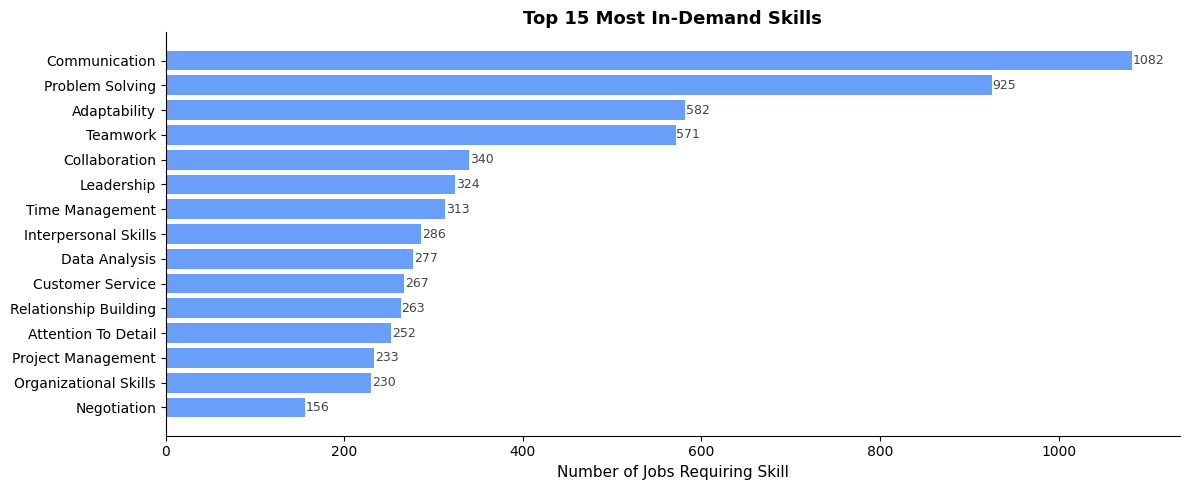

In [9]:
# ── Visualize top 15 skills ──────────────────────────────
top15 = top_skills[:15]
skill_names  = [s[0].title() for s in top15]
skill_counts = [s[1] for s in top15]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(skill_names[::-1], skill_counts[::-1], color='#4F8EF7', alpha=0.85)
ax.set_xlabel('Number of Jobs Requiring Skill', fontsize=11)
ax.set_title('Top 15 Most In-Demand Skills', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, skill_counts[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9, color='#444')
plt.tight_layout()
plt.show()

## 6. Skill Extraction from Resume Text

In [33]:
# ════════════════════════════════════════════════════════
# SKILL EXTRACTION FROM RESUME
# ════════════════════════════════════════════════════════

import re


# ------------------------------------------------
# FUNCTION → Extract Skills
# ------------------------------------------------

def extract_skills_from_text(resume_text, known_skills):

    """
    Resume text se known skills find karta hai
    using regex matching.
    """



    # ------------------------------------------------
    # STEP 1 → Empty input check
    # ------------------------------------------------

  
    if not resume_text or not known_skills:
        return []



    # ------------------------------------------------
    # STEP 2 → Lowercase conversion
    # ------------------------------------------------

   

    text = str(resume_text).lower()



    # ------------------------------------------------
    # STEP 3 → Apply skill aliases
    # ------------------------------------------------

   
    for alias, canonical in SKILL_ALIASES.items():



        # ----------------------------------------
        # Regex pattern
        # ----------------------------------------

       

        pattern = (

            r'(?<![a-z0-9])'

            +

            re.escape(alias.lower())

            +

            r'(?![a-z0-9])'

        )



        # ----------------------------------------
        # Replace alias with standard skill
        # ----------------------------------------

        text = re.sub(

            pattern,

            ' ' + canonical.lower() + ' ',

            text
        )



    # ------------------------------------------------
    # STEP 4 → Store matched skills
    # ------------------------------------------------

    matched_skills = set()



    # ------------------------------------------------
    # STEP 5 → Check every known skill
    # ------------------------------------------------

    for skill in known_skills:



        # Small/invalid skills skip
        if not skill or len(skill) < 2:
            continue



        # ----------------------------------------
        # Regex pattern
        # ----------------------------------------

        pattern = (

            r'(?<![a-z0-9])'

            +

            re.escape(skill.lower())

            +

            r'(?![a-z0-9])'

        )



        # ----------------------------------------
        # Skill match check
        # ----------------------------------------

        if re.search(pattern, text):

            matched_skills.add(skill)



    # ------------------------------------------------
    # STEP 6 → Sorted result return
    # ------------------------------------------------

    return sorted(matched_skills)



# ════════════════════════════════════════════════════════
# SAMPLE TEST
# ════════════════════════════════════════════════════════

sample_resume = """

John Doe | Python Developer

Skills:

Python,
TensorFlow,
Scikit-Learn,
SQL,
Docker,
REST APIs,
Git,
Agile,
Data Analysis,
Machine Learning

3 years experience in data science.

"""


# Function call
detected = extract_skills_from_text(

    sample_resume,

    skill_vocab
)



# Output
print(

    f"Detected {len(detected)} skills:\n"

)

print(

    ', '.join(

        skill.title()

        for skill in detected
    )
)

Detected 10 skills:

Agile, Data Analysis, Data Science, Docker, Git, Machine Learning, Python, Rest, Rest Apis, Sql


## 7. Feature Engineering

Skills per Job Statistics:

count    1157.0
mean       17.9
std         5.0
min         5.0
25%        15.0
50%        18.0
75%        20.0
max        43.0
Name: n_skills, dtype: float64


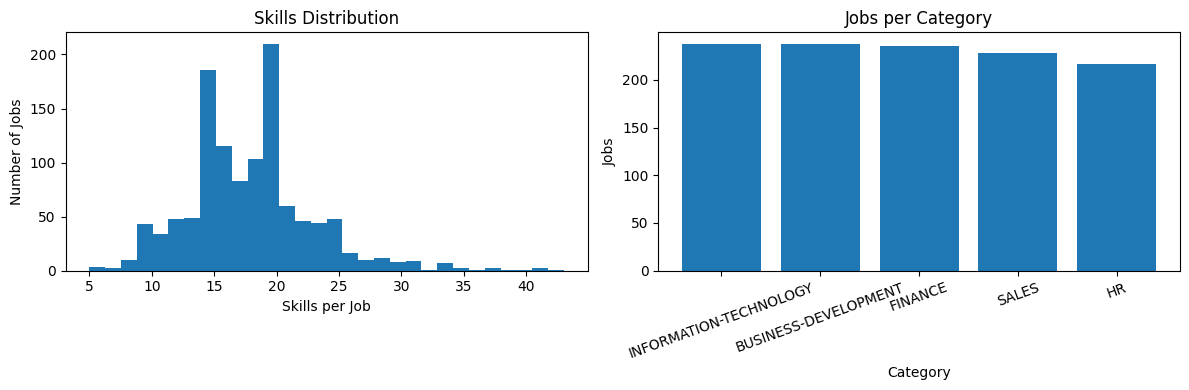

In [34]:
# ════════════════════════════════════════════════════════
# DATA VISUALIZATION
# Skills Analysis + Category Analysis
# ════════════════════════════════════════════════════════

import matplotlib.pyplot as plt



# ------------------------------------------------
# STEP 1 → Har job me kitni skills hain
# ------------------------------------------------


df['n_skills'] = df['skills_list'].apply(len)



# ------------------------------------------------
# STEP 2 → Statistics show karo
# ------------------------------------------------

print("Skills per Job Statistics:\n")


print(

    df['n_skills']
    .describe()
    .round(1)

)





fig, axes = plt.subplots(

    1,          # rows
    2,          # columns

    figsize=(12, 4)
)



# ════════════════════════════════════════════════
# GRAPH 1 → Skills Distribution
# ════════════════════════════════════════════════

axes[0].hist(

    df['n_skills'],

    bins=30
)




axes[0].set_xlabel(

    'Skills per Job'
)




axes[0].set_ylabel(

    'Number of Jobs'
)



# Graph title
axes[0].set_title(

    'Skills Distribution'
)



# ------------------------------------------------
# STEP 4 → Category Counts
# ------------------------------------------------



category_counts = (

    df['category']
    .value_counts()

)

axes[1].bar(

    category_counts.index,

    category_counts.values

)



axes[1].set_xlabel(

    'Category'
)



axes[1].set_ylabel(

    'Jobs'
)




axes[1].set_title(

    'Jobs per Category'
)




axes[1].tick_params(

    axis='x',

    rotation=20
)


plt.tight_layout()

plt.show()

## 8. TF-IDF Vectorization

In [17]:
# =====================================================
# IMPORT TF-IDF VECTORIZER
# =====================================================

from sklearn.feature_extraction.text import TfidfVectorizer



# =====================================================
# SKILL TF-IDF VECTORIZER
# =====================================================

skill_vec = TfidfVectorizer(

    ngram_range=(1, 2),

    min_df=CONFIG['skill_min_df'],
    

    max_df=CONFIG['skill_max_df'],
    

    sublinear_tf=True,
    
)


skill_matrix = skill_vec.fit_transform(df['skills_text'])


print(f'Skill TF-IDF matrix shape : {skill_matrix.shape}')


print(f'Skill vocabulary size     : {len(skill_vec.vocabulary_):,}')


# =====================================================
# DESCRIPTION TF-IDF VECTORIZER
# =====================================================

desc_vec = TfidfVectorizer(

    ngram_range=(1, 2),


    min_df=CONFIG['desc_min_df'],
    

    max_df=CONFIG['desc_max_df'],
    

    sublinear_tf=True,
    

    max_features=CONFIG['desc_max_features'],
    
)

# Agar description bahut choti hai
# to skills_text use karo

desc_corpus = df['desc_clean'].where(

    df['desc_clean'].str.len() > 30,
    

    df['skills_text']
   
)


desc_matrix = desc_vec.fit_transform(desc_corpus)


print(f'\nDesc TF-IDF matrix shape  : {desc_matrix.shape}')


print(f'Desc vocabulary size      : {len(desc_vec.vocabulary_):,}')

Skill TF-IDF matrix shape : (1157, 17741)
Skill vocabulary size     : 17,741

Desc TF-IDF matrix shape  : (1157, 10000)
Desc vocabulary size      : 10,000


## 9. Experience Level Detection

In [18]:
# =====================================================
# IMPORT REGEX MODULE
# =====================================================

import re



# =====================================================
# EXPERIENCE LEVEL PATTERNS
# =====================================================

EXPERIENCE_PATTERNS = {

    # -------------------------------------------------
    # SENIOR LEVEL PATTERNS
    # -------------------------------------------------

    'Senior': [

        r'\b(1[0-9]|20|\d{2})\+?\s*(years?|yrs?)\b',
       
        r'\b(8|9)\+?\s*(years?|yrs?)\b',
       

        r'\b(senior|lead|principal|staff|head|director|manager|cto|cfo)\b',
        

        r'\bmanag(ed|ing)\s+(team|people|staff|engineers)\b',
       
        
    ],

    # -------------------------------------------------
    # MID LEVEL PATTERNS
    # -------------------------------------------------

    'Mid': [

        r'\b([4-7])\+?\s*(years?|yrs?)\b',
        

        r'\b(mid.level|intermediate|experienced|associate)\b',
        
    ],

    # -------------------------------------------------
    # ENTRY LEVEL PATTERNS
    # -------------------------------------------------

    'Entry': [

        r'\b([0-3])\+?\s*(years?|yrs?)\b',
       

        r'\b(fresher|graduate|intern|entry.level|junior|trainee|recent\s*grad)\b',
        
    ],
}


# =====================================================
# EXPERIENCE DETECTION FUNCTION
# =====================================================

def detect_experience_level(text):

    
    text_lower = str(text).lower()

    
    for level in ['Senior', 'Mid', 'Entry']:

        
        for pat in EXPERIENCE_PATTERNS[level]:

            
            if re.search(pat, text_lower):

                
                return level

  
    return 'Mid'


# =====================================================
# TEST CASES
# =====================================================

tests = [

    (
        'Senior ML Engineer with 10 years experience',
        'Senior'
    ),

    (
        'Junior Python developer, 1 year experience',
        'Entry'
    ),

    (
        'Data Scientist with 5 years in analytics',
        'Mid'
    ),

    (
        'Recent graduate looking for first role',
        'Entry'
    ),
]


# =====================================================
# RUN TESTS
# =====================================================

print('Experience Detection Tests:\n')


for text, expected in tests:

    
    result = detect_experience_level(text)

   
    status = '✅' if result == expected else '❌'

   
    print(f'{status}  "{text}" → {result}')

Experience Detection Tests:

✅  "Senior ML Engineer with 10 years experience" → Senior
✅  "Junior Python developer, 1 year experience" → Entry
✅  "Data Scientist with 5 years in analytics" → Mid
✅  "Recent graduate looking for first role" → Entry


## 10. Helper Functions

In [19]:
# =====================================================
# IMPORT LIBRARY
# =====================================================

from difflib import SequenceMatcher
# SequenceMatcher string similarity compare karne ke liye use hota hai


# =====================================================
# FUNCTION 1 : RANK SKILLS BY DEMAND
# =====================================================

def rank_by_demand(missing_skills, skill_freq, max_n=8):

   
    # max_n = maximum kitni skills return karni hain

    ranked_skills = sorted(

        missing_skills,
        

        key=lambda skill: skill_freq.get(skill, 0),
       

        reverse=True
        
    )

    # Top demanded skills return karo
    return ranked_skills[:max_n]


# =====================================================
# FUNCTION 2 : GET MATCH TIER
# =====================================================

def get_tier(match_percent):

   
    if match_percent >= 80:
        return "Excellent Match", "🟢"

   
    elif match_percent >= 60:
        return "Good Match", "🟡"

    
    elif match_percent >= 40:
        return "Average Match", "🟠"

   
    else:
        return "Weak Match", "🔴"


# =====================================================
# FUNCTION 3 : REMOVE DUPLICATE TITLES
# =====================================================

def is_duplicate_title(title, seen_titles, threshold=0.82):

    
    title_lower = title.lower()

    # Har already-seen title ke saath compare karo
    for old_title in seen_titles:

       
        similarity = SequenceMatcher(

            None,
            

            title_lower,
           

            old_title.lower()
            
        ).ratio()

        # ratio() similarity score deta hai
        # Range = 0 to 1

       
        if similarity >= threshold:

            # Duplicate title hai
            return True

    # Duplicate nahi mila
    return False


# =====================================================
# FUNCTION 4 : EXPERIENCE PENALTY
# =====================================================

def apply_exp_penalty(scores, titles, exp_level):

    
    if exp_level == 'Mid':
        return scores

    # Original scores ko safe rakhne ke liye copy banao
    scores = scores.copy()

    # Entry-level keywords
    entry_keywords = [

        'junior',
        'trainee',
        'intern',
        'graduate',
        'fresher',
        'entry'
    ]

    # Senior-level keywords
    senior_keywords = [

        'senior',
        'lead',
        'principal',
        'head',
        'director',
        'manager',
        'vp'
    ]

    # Har title ko loop mai check karo
    for i, title in enumerate(titles):

       
        title_lower = title.lower()

        # =========================================
        # CASE 1 : Senior user applying for entry jobs
        # =========================================

        if exp_level == 'Senior':

            
            if any(word in title_lower for word in entry_keywords):

                # Score ko 15% reduce karo
                scores[i] *= 0.85

        # =========================================
        # CASE 2 : Entry user applying for senior jobs
        # =========================================

        elif exp_level == 'Entry':

           
            if any(word in title_lower for word in senior_keywords):

                
                scores[i] *= 0.85

   
    return scores


# =====================================================
# SUCCESS MESSAGE
# =====================================================

print('✅ All helper functions defined')

✅ All helper functions defined


## 11. Recommendation Engine

In [35]:
# =====================================================
# MAIN RECOMMENDATION FUNCTION
# =====================================================

def recommend_jobs(

    resume_text,
    

    df,
    

    skill_vec,
    

    skill_matrix,
    

    desc_vec,
   

    desc_matrix,
    

    skill_vocab,
   

    skill_freq,
   

    category_filter='All',
   

    top_n=5,
    # Top recommendations count
):


    # =================================================
    # FUNCTION DESCRIPTION
    # =================================================

    """
    Hybrid recommendation system

    Final Score =
    70% Skill Similarity
    +
    30% Description Similarity
    """


    # =================================================
    # WEIGHTS
    # =================================================

    W_SKILL = CONFIG['skill_weight']
   

    W_DESC = CONFIG['desc_weight']
    


    # =================================================
    # STEP 1 : EXTRACT SKILLS
    # =================================================

    resume_skills = extract_skills_from_text(

        resume_text,

        skill_vocab
    )

   


    # =================================================
    # STEP 2 : DETECT EXPERIENCE LEVEL
    # =================================================

    exp_level = detect_experience_level(
        resume_text
    )

    


    # =================================================
    # STEP 3 : CONVERT SKILLS TO SET
    # =================================================

    resume_skill_s = set(
        resume_skills
    )

    # Fast matching ke liye set use kiya


    # =================================================
    # STEP 4 : PREPARE INPUT TEXT
    # =================================================

    skill_input = ' '.join(
        resume_skills
    )

    


   

    if not resume_skills:

        skill_input = clean_text(
            resume_text
        )


    desc_input = clean_text(

        resume_text,

        remove_stopwords=True
    )

    # Resume text clean karo


    # =================================================
    # STEP 5 : CHECK EMPTY INPUT
    # =================================================

    if not skill_input.strip():

        print('⚠ No skills found in resume text.')

        return []


    # =================================================
    # STEP 6 : TF-IDF TRANSFORM
    # =================================================

    try:

        rv_skill = skill_vec.transform(
            [skill_input]
        )

        # Resume skills ko TF-IDF vector mai convert karo


        rv_desc = desc_vec.transform(
            [desc_input]
        )

        # Resume description ko TF-IDF vector mai convert karo


    except Exception as e:

        print(f'Transform error: {e}')

        return []


    # =================================================
    # STEP 7 : CATEGORY FILTER
    # =================================================

    if category_filter and category_filter != 'All':

        # Category matching rows select karo
        mask = df['category'] == category_filter


        # Filtered dataframe
        fdf = df[mask].copy()


        # Filtered indexes
        idx = fdf.index.to_numpy()

    else:

        fdf = df.copy()

        idx = np.arange(len(df))


    # =================================================
    # CHECK EMPTY DATAFRAME
    # =================================================

    if fdf.empty:

        print('⚠ No jobs found for this category filter.')

        return []


    # =================================================
    # STEP 8 : COSINE SIMILARITY
    # =================================================

    skill_sim = cosine_similarity(

        rv_skill,

        skill_matrix[idx]

    ).flatten()

    # Resume skills vs job skills similarity


    desc_sim = cosine_similarity(

        rv_desc,

        desc_matrix[idx]

    ).flatten()

    # Resume description vs job description similarity


    # =================================================
    # STEP 9 : HYBRID SCORE
    # =================================================

    hybrid = (

        W_SKILL * skill_sim +

        W_DESC * desc_sim
    )

   
    
    # =================================================
    # STEP 10 : EXPERIENCE PENALTY
    # =================================================

    titles = fdf['job_title'].to_numpy()

    # Job titles numpy array mai convert karo


    hybrid = apply_exp_penalty(

        hybrid,

        titles,

        exp_level
    )

    # Experience mismatch par score reduce karo


    # =================================================
    # STEP 11 : CANDIDATE POOL
    # =================================================

    n_cand = min(

        top_n *

        CONFIG['candidate_multiplier'],

        len(hybrid)
    )




    cand_idx = np.argsort(

        hybrid

    )[::-1][:n_cand]




    # =================================================
    # STEP 12 : RESULT STORAGE
    # =================================================

    results = []
 

    seen_titles = []
    

    cat_count = {}
  


    cat_max = max(

        1,

        int(
            top_n *
            CONFIG['category_cap']
        )
    )

    for i in cand_idx:

        score = float(
            hybrid[i]
        )

        if score <= 0.0:
            break


        row = fdf.iloc[int(i)]
       


        job_title = str(
            row['job_title']
        )

       


        category = str(
            row['category']
        )

        


        job_skills = set(
            row['skills_list']
        )

        if not job_skills:
            continue


        # =================================================
        # REMOVE DUPLICATE TITLES
        # =================================================

        if is_duplicate_title(

            job_title,

            seen_titles
        ):

            continue


        # =================================================
        # CATEGORY LIMIT CHECK
        # =================================================

        if cat_count.get(
            category,
            0
        ) >= cat_max:

            continue


        # =================================================
        # MATCHED SKILLS
        # =================================================

        matched = sorted(

            job_skills & resume_skill_s
        )

        


        # =================================================
        # MISSING SKILLS
        # =================================================

        missing = sorted(

            job_skills - resume_skill_s
        )

   
        recommended = rank_by_demand(

            missing,

            skill_freq,

            max_n=8
        )



        # =================================================
        # MATCH PERCENTAGE
        # =================================================

        match_pct = round(

            len(matched)

            /

            len(job_skills)

            * 100,

            1
        )

  


        # =================================================
        # MATCH TIER
        # =================================================

        tier, icon = get_tier(
            match_pct
        )

        results.append({

            'rank': len(results) + 1,

            'job_title': job_title,

            'category': category,

            'match_pct': match_pct,

            'hybrid_score': round(
                score * 100,
                2
            ),

            'skill_score': round(

                float(skill_sim[int(i)])
                * 100,

                2
            ),

            'desc_score': round(

                float(desc_sim[int(i)])
                * 100,

                2
            ),

            'tier': tier,

            'tier_icon': icon,

            'experience_level': exp_level,

            'matched_skills': matched,

            'missing_skills': missing,

            'recommended_skills': recommended,

            'total_job_skills': len(job_skills),
        })


        # =================================================
        # UPDATE TRACKERS
        # =================================================

        seen_titles.append(
            job_title.lower()
        )



        cat_count[category] = (

            cat_count.get(
                category,
                0
            ) + 1
        )

        if len(results) >= top_n:
            break


    # =================================================
    # FINAL SORTING
    # =================================================

    results.sort(

        key=lambda x: (

            x['match_pct'],

            x['hybrid_score']
        ),

        reverse=True
    )



    # =================================================
    # RETURN FINAL RESULTS
    # =================================================

    return results[:top_n]


print('✅ Recommendation engine defined')

✅ Recommendation engine defined


## 12. Demo Run — Recommendation Test

In [ ]:
# =====================================================
# SAMPLE RESUME
# =====================================================

DEMO_RESUME = """

Jane Smith | Data Scientist

Experience: 4 years in data science and machine learning.

Skills:

Python,
Pandas,
NumPy,
Scikit-Learn,
TensorFlow,
SQL,
Tableau,
Power BI,
Excel,
Docker,
Git,
Machine Learning,
Deep Learning,
Data Analysis,
Natural Language Processing

"""


# =====================================================
# RUN JOB RECOMMENDATION SYSTEM
# =====================================================

results = recommend_jobs(

    resume_text=DEMO_RESUME,
   

    df=df,
 

    skill_vec=skill_vec,
   

    skill_matrix=skill_matrix,
   

    desc_vec=desc_vec,
   

    desc_matrix=desc_matrix,
  

    skill_vocab=skill_vocab,
    

    skill_freq=skill_freq,
   

    category_filter='All',
    

    top_n=5
    
)


# =====================================================
# EXTRACT DETECTED SKILLS
# =====================================================

detected_skills = extract_skills_from_text(

    DEMO_RESUME,

    skill_vocab
)



# =====================================================
# DETECT EXPERIENCE LEVEL
# =====================================================

experience_level = detect_experience_level(

    DEMO_RESUME
)


print(

    f'Found : {len(results)} recommendations'
)




print(

    f'Detected Skills : {len(detected_skills)}'
)




print(

    f'Experience Level : {experience_level}'
)



Found : 5 recommendations
Detected Skills : 10
Experience Level : Mid


In [37]:
# ════════════════════════════════════════════════════════
# DISPLAY RESULTS
# ════════════════════════════════════════════════════════

for job in results:
    print('=' * 60)
    print(f"#{job['rank']:02d} {job['job_title']} | {job['category']}")
    print(f"{job['tier_icon']} {job['tier']} | Match: {job['match_pct']}% | Hybrid: {job['hybrid_score']}%")

    matched = ', '.join(s.title() for s in job['matched_skills'][:6])
    missing = ', '.join(s.title() for s in job['missing_skills'][:6])
    learn   = ', '.join(s.title() for s in job['recommended_skills'][:5])

    print(f"Matched ({len(job['matched_skills'])}): {matched}")
    print(f"Missing ({len(job['missing_skills'])}): {missing}")
    print(f"Learn  : {learn}")
    print()

#02 Data Solutions Analyst Ii (Managed Care - Finance Focus) - R7269 | FINANCE
🔴 Weak Match | Match: 29.4% | Hybrid: 18.25%
Matched (5): Data Analysis, Power Bi, Python, Sql, Tableau
Missing (12): Adaptability, Attention To Detail, Azure, Collaboration, Communication, Data Modeling
Learn  : Communication, Problem Solving, Adaptability, Collaboration, Attention To Detail

#04 Information Technology Programmer | INFORMATION-TECHNOLOGY
🔴 Weak Match | Match: 25.0% | Hybrid: 13.6%
Matched (4): Data Analysis, Excel, Power Bi, Sql
Missing (12): Attention To Detail, C#, Communication, Critical Thinking, Dashboard Development, Database Management
Learn  : Communication, Problem Solving, Attention To Detail, Critical Thinking, Technical Support

#03 Staff Data Engineer - People & Finance Tech (Remote) | FINANCE
🔴 Weak Match | Match: 13.5% | Hybrid: 14.82%
Matched (5): Docker, Git, Power Bi, Python, Sql
Missing (32): Adaptability, Azure, Big Data, C#, Ci/Cd, Collaboration
Learn  : Communication, 

## 13. Skill Gap Analysis

In [38]:




# =====================================================
# COLLECT ALL MISSING SKILLS
# =====================================================

all_missing = [

    skill

    for job in results

    for skill in job['missing_skills']
]



# =====================================================
# COLLECT ALL MATCHED SKILLS
# =====================================================

all_matched = [

    skill

    for job in results

    for skill in job['matched_skills']
]



top_missing = Counter(

    all_missing

).most_common(10)

top_matched = Counter(

    all_matched

).most_common(10)



max_len = max(

    len(top_missing),

    len(top_matched)
)



# =====================================================
# PAD MISSING SKILLS LIST
# =====================================================

top_missing_padded = (

    top_missing +

    [('', 0)] *

    (max_len - len(top_missing))
)



# =====================================================
# PAD MATCHED SKILLS LIST
# =====================================================

top_matched_padded = (

    top_matched +

    [('', 0)] *

    (max_len - len(top_matched))
)




# =====================================================
# CREATE DATAFRAME
# =====================================================

gap_df = pd.DataFrame({

    
    'Missing Skill': [

        skill.title()

        for skill, count in top_missing_padded
    ],

    
    'Jobs Requiring': [

        count

        for skill, count in top_missing_padded
    ],

   
    'Your Strength': [

        skill.title()

        for skill, count in top_matched_padded
    ],

    
    'Jobs Matched': [

        count

        for skill, count in top_matched_padded
    ],
})

# Final comparison table create karo


# =====================================================
# UPDATE INDEX
# =====================================================

gap_df.index = range(

    1,

    len(gap_df) + 1
)



print('Skill Gap Analysis:\n')


display(gap_df)

# Final DataFrame display karo

Skill Gap Analysis:



,Missing Skill,Jobs Requiring,Your Strength,Jobs Matched
1,Communication,4,Power Bi,4
2,Adaptability,3,Data Analysis,3
3,Problem Solving,3,Python,3
4,Attention To Detail,2,Sql,3
5,Azure,2,Machine Learning,2
6,Collaboration,2,Tableau,1
7,Etl,2,Excel,1
8,C#,2,Docker,1
9,Java,2,Git,1
10,Organizational Skills,2,Data Science,1


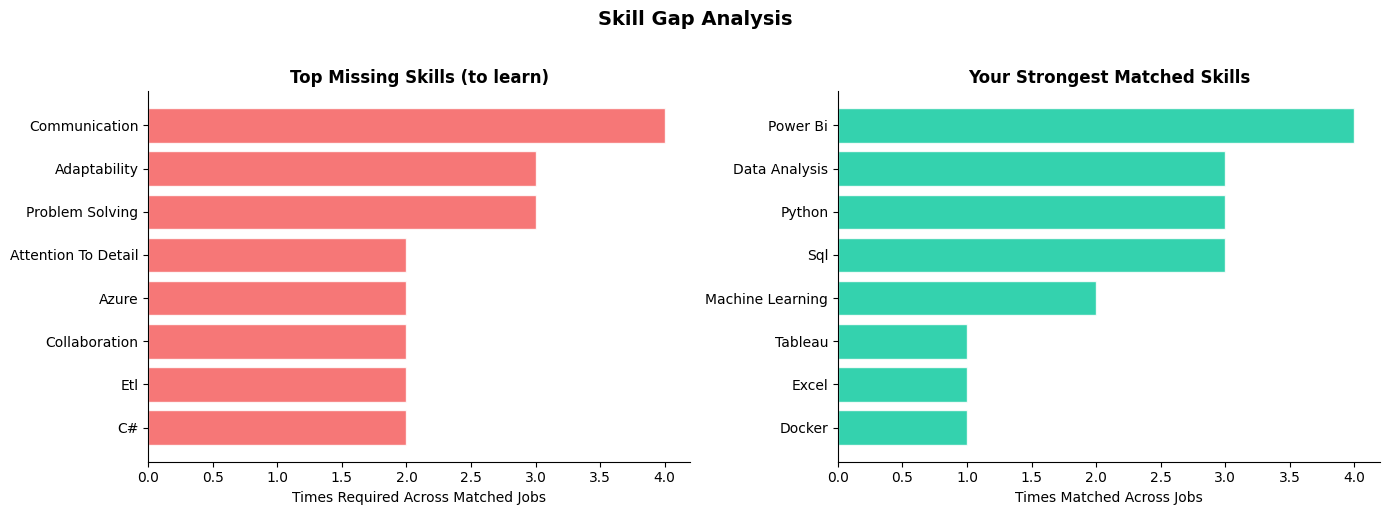

In [25]:
# ── Skill gap chart ───────────────────────────────────────
if top_missing and top_matched:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Missing skills
    m_skills = [s.title() for s, _ in top_missing[:8]][::-1]
    m_counts = [c for _, c in top_missing[:8]][::-1]
    axes[0].barh(m_skills, m_counts, color='#F55F5F', alpha=0.85, edgecolor='white')
    axes[0].set_title('Top Missing Skills (to learn)', fontweight='bold')
    axes[0].set_xlabel('Times Required Across Matched Jobs')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Matched skills
    t_skills = [s.title() for s, _ in top_matched[:8]][::-1]
    t_counts = [c for _, c in top_matched[:8]][::-1]
    axes[1].barh(t_skills, t_counts, color='#10CBA0', alpha=0.85, edgecolor='white')
    axes[1].set_title('Your Strongest Matched Skills', fontweight='bold')
    axes[1].set_xlabel('Times Matched Across Jobs')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.suptitle('Skill Gap Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

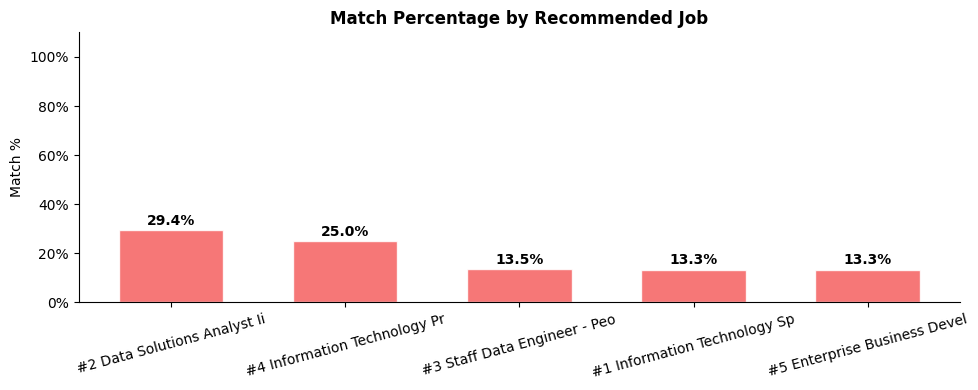

In [26]:
# ── Match % bar chart ─────────────────────────────────────
if results:
    job_labels  = [f"#{r['rank']} {r['job_title'][:25]}" for r in results]
    match_pcts  = [r['match_pct'] for r in results]
    bar_colors  = [
        '#10CBA0' if p >= 70 else
        '#F5A623' if p >= 45 else
        '#F55F5F'
        for p in match_pcts
    ]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(job_labels, match_pcts, color=bar_colors, alpha=0.85, edgecolor='white', width=0.6)
    ax.set_ylim(0, 110)
    ax.set_ylabel('Match %')
    ax.set_title('Match Percentage by Recommended Job', fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, match_pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    plt.tight_layout()
    plt.show()

## 14. Evaluation & Diagnostics

In [39]:
# =====================================================
# EVALUATION DIAGNOSTICS
# =====================================================


if results:


    print('Category Distribution:\n')

  
    category_counts = Counter(

        result['category']

        for result in results
    )

    for category, count in category_counts.items():

        # Percentage calculate karo
        percentage = (

            count /

            len(results)

            * 100
        )

        print(

            f'{category} : '

            f'{count} jobs '

            f'({percentage:.0f}%)'
        )


    # =================================================
    # UNIQUE TITLES
    # =================================================

    unique_titles = len(

        set(

            result['job_title']

            for result in results
        )
    )



    print(

        f'\nUnique Titles : '

        f'{unique_titles}'
    )


    # =================================================
    # MATCH SCORES
    # =================================================

    match_scores = [

        result['match_pct']

        for result in results
    ]



    hybrid_scores = [

        result['hybrid_score']

        for result in results
    ]

 


    # =================================================
    # SCORE STATISTICS
    # =================================================

    print('\nScore Statistics:\n')


    print(

        f'Min Match % : '

        f'{min(match_scores):.1f}'
    )


    print(

        f'Max Match % : '

        f'{max(match_scores):.1f}'
    )


 
 
    print(

        f'Average Match % : '

        f'{sum(match_scores)/len(match_scores):.1f}'
    )


   
   
    print(

        f'Min Hybrid Score : '

        f'{min(hybrid_scores):.2f}'
    )


    
    print(

        f'Max Hybrid Score : '

        f'{max(hybrid_scores):.2f}'
    )


else:

    print('⚠ No results found')

Category Distribution:

FINANCE : 2 jobs (40%)
INFORMATION-TECHNOLOGY : 2 jobs (40%)
BUSINESS-DEVELOPMENT : 1 jobs (20%)

Unique Titles : 5

Score Statistics:

Min Match % : 13.3
Max Match % : 29.4
Average Match % : 18.9
Min Hybrid Score : 12.19
Max Hybrid Score : 20.22


## 15. Save Artifacts

In [40]:
# =====================================================
# IMPORT REQUIRED LIBRARIES
# =====================================================

from scipy import sparse

out = Path(

    CONFIG['output_dir']
)



# =====================================================
# 1. SAVE PROCESSED DATASET
# =====================================================

df.drop(

    columns=['job_description'],
    # Raw job description column remove karo

    errors='ignore'
    # Agar column nahi hai to error mat do

).to_parquet(

    out / 'processed_jobs.parquet',
    # File path

    index=False
    
)




print('✅ Saved processed_jobs.parquet')


# =====================================================
# 2. SAVE SKILL TF-IDF VECTORIZER
# =====================================================

with open(

    out / 'skill_vectorizer.pkl',

    'wb'
    

) as f:

    pickle.dump(

        skill_vec,

        f
    )

   


print('✅ Saved skill_vectorizer.pkl')


# =====================================================
# 3. SAVE DESCRIPTION TF-IDF VECTORIZER
# =====================================================

with open(

    out / 'desc_vectorizer.pkl',

    'wb'

) as f:

    pickle.dump(

        desc_vec,

        f
    )



print('✅ Saved desc_vectorizer.pkl')


# =====================================================
# 4. SAVE SKILL VOCABULARY + FREQUENCY
# =====================================================

with open(

    out / 'skill_vocab.pkl',

    'wb'

) as f:

    pickle.dump(

        {
            'vocab': skill_vocab,
           

            'freq': skill_freq
           
        },

        f
    )

 


print('✅ Saved skill_vocab.pkl')


# =====================================================
# 5. SAVE SPARSE MATRICES
# =====================================================

sparse.save_npz(

    str(out / 'skill_matrix.npz'),

    skill_matrix
)



sparse.save_npz(

    str(out / 'desc_matrix.npz'),

    desc_matrix
)


print(

    '✅ Saved skill_matrix.npz and desc_matrix.npz'
)


# =====================================================
# FINAL SUCCESS MESSAGE
# =====================================================

print(

    f'\n📦 All artifacts saved to: '

    f'{out.resolve()}'
)



✅ Saved processed_jobs.parquet
✅ Saved skill_vectorizer.pkl
✅ Saved desc_vectorizer.pkl
✅ Saved skill_vocab.pkl
✅ Saved skill_matrix.npz and desc_matrix.npz

📦 All artifacts saved to: C:\Users\amard\OneDrive\Desktop\job_recommender_v3\artifacts


In [41]:
# =====================================================
# LOAD SAVED ARTIFACTS
# =====================================================

def load_artifacts(
       

    artifact_dir='./artifacts'
    
):

    """
    Saved files load karega
    aur ready-to-use objects return karega
    """


    # =================================================
    # CREATE FOLDER PATH
    # =================================================

    artifact_path = Path(
        artifact_dir
    )

  


    # =================================================
    # LOAD PROCESSED DATAFRAME
    # =================================================

    df_loaded = pd.read_parquet(

        artifact_path /

        'processed_jobs.parquet'
    )



    # =================================================
    # CHECK skills_list COLUMN
    # =================================================

    if 'skills_list' not in df_loaded.columns:


        df_loaded['skills_list'] = (

            df_loaded['skills_text']

            .fillna('')
            

            .apply(

                lambda text: text.split()
            )
            
        )


    # =================================================
    # LOAD SKILL VECTORIZER
    # =================================================

    with open(

        artifact_path /

        'skill_vectorizer.pkl',

        'rb'
        
    ) as f:

        sv = pickle.load(f)

       


    # =================================================
    # LOAD DESCRIPTION VECTORIZER
    # =================================================

    with open(

        artifact_path /

        'desc_vectorizer.pkl',

        'rb'

    ) as f:

        dv = pickle.load(f)

     

    # =================================================
    # LOAD VOCABULARY + FREQUENCY
    # =================================================

    with open(

        artifact_path /

        'skill_vocab.pkl',

        'rb'

    ) as f:

        vd = pickle.load(f)

        # Vocabulary dictionary load karo


    # =================================================
    # LOAD SKILL MATRIX
    # =================================================

    sm = sparse.load_npz(

        str(
            artifact_path /

            'skill_matrix.npz'
        )
    )

   


    # =================================================
    # LOAD DESCRIPTION MATRIX
    # =================================================

    dm = sparse.load_npz(

        str(
            artifact_path /

            'desc_matrix.npz'
        )
    )

 


    # =================================================
    # PRINT DATA INFO
    # =================================================

    print(

        f'Loaded Jobs : '

        f'{len(df_loaded):,}'
    )


    print(

        f'Loaded Skills : '

        f'{len(vd["vocab"]):,}'
    )

  


    # =================================================
    # RETURN ALL OBJECTS
    # =================================================

    return (

        df_loaded,
       

        sv,
       

        sm,
        

        dv,
        

        dm,
        

        vd['vocab'],
        

        vd['freq']
        
    )


# =====================================================
# TEST LOADING
# =====================================================

df_l, sv_l, sm_l, dv_l, dm_l, vocab_l, freq_l = load_artifacts()


print(

    '\n✅ Artifacts loaded successfully'

    ' — pipeline ready for inference'
)



Loaded Jobs : 1,157
Loaded Skills : 4,973

✅ Artifacts loaded successfully — pipeline ready for inference


---
## ✅ Pipeline Complete

| Artifact | Description |
|----------|-------------|
| `processed_jobs.parquet` | Cleaned, deduplicated job DataFrame |
| `skill_vectorizer.pkl` | TF-IDF trained on skill strings |
| `desc_vectorizer.pkl` | TF-IDF trained on job descriptions |
| `skill_vocab.pkl` | All skills + frequency dict |
| `skill_matrix.npz` | Sparse skill TF-IDF matrix |
| `desc_matrix.npz` | Sparse description TF-IDF matrix |

**Next steps:**
- Run `python -m streamlit run app.py` to launch the web app
- Tune `skill_weight` / `desc_weight` in CONFIG to adjust scoring
- Change `top_n` in CONFIG to get more/fewer recommendations